<a href="https://colab.research.google.com/github/hasinduwelikala/northstar-databases-analytics/blob/main/03_Python_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import urllib.request


In [33]:
BASE_URL = "https://raw.githubusercontent.com/hasinduwelikala/northstar-databases-analytics/main/data/"

FILES = [
    "orders.csv", "deliveries.csv", "hubs.csv", "customers.csv",
    "complaints.csv", "drivers.csv", "vehicles.csv", "incidents.csv",
    "app_events.csv", "data_dictionary.csv"
]

def download_files(base_url, file_list):
    for f in file_list:
        urllib.request.urlretrieve(base_url + f, f)
    print("All files downloaded.")

download_files(BASE_URL, FILES)

All files downloaded.


In [34]:
orders     = pd.read_csv("orders.csv",     na_values=["", " "])
deliveries = pd.read_csv("deliveries.csv", na_values=["", " "])
hubs       = pd.read_csv("hubs.csv",       na_values=["", " "])
customers  = pd.read_csv("customers.csv",  na_values=["", " "])
complaints = pd.read_csv("complaints.csv", na_values=["", " "])
drivers    = pd.read_csv("drivers.csv",    na_values=["", " "])
vehicles   = pd.read_csv("vehicles.csv",   na_values=["", " "])
incidents  = pd.read_csv("incidents.csv",  na_values=["", " "])
app_events = pd.read_csv("app_events.csv", na_values=["", " "])


print("=== orders — first 5 rows ===")
print(orders.head())


print("\n=== deliveries — basic info ===")
deliveries.info()


print("\n=== deliveries — descriptive statistics ===")
print(deliveries.describe())


=== orders — first 5 rows ===
  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      AIRPORT            Low       109.30   
2                      4        West      AIRPORT           High        33.50   
3                      2   RiverSide        North         Medium        10.04   
4                     12   Riverside        SOUTH            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                   


=== Missing value count per column ===

orders:
  booking_channel: 25 missing

deliveries:
  delivery_completed_at: 19 missing
  customer_rating_post_delivery: 14 missing

customers:
  loyalty_score: 20 missing
  preferred_channel: 13 missing

complaints:
  compensation_amount: 16 missing

drivers:
  training_score: 7 missing

vehicles:
  battery_health_pct: 4 missing

incidents:
  resolved_hours: 17 missing


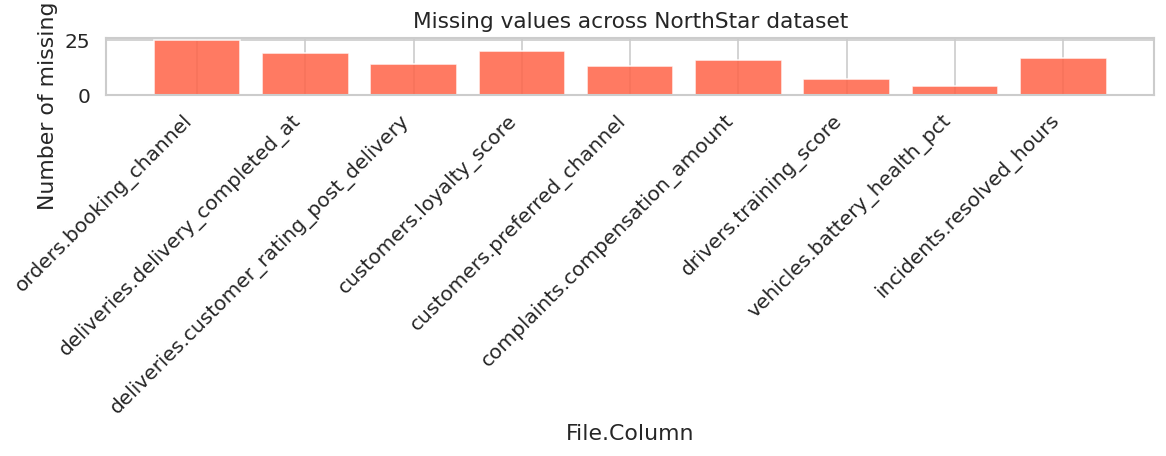


Interpretation: All missing rates are below 5% — safe for median/mode imputation without introducing significant bias.


In [35]:
print("\n=== Missing value count per column ===")

missing_dict = {}
for name, df in {"orders": orders, "deliveries": deliveries,
                  "customers": customers, "complaints": complaints,
                  "drivers": drivers, "vehicles": vehicles,
                  "incidents": incidents}.items():
    missing_dict[name] = df.isnull().sum().to_dict()
    print(f"\n{name}:")
    for col, count in missing_dict[name].items():
        if count > 0:
            print(f"  {col}: {count} missing")


missing_summary = []
for name, col_dict in missing_dict.items():
    for col, count in col_dict.items():
        if count > 0:
            missing_summary.append({"file": name, "column": col, "missing": count})

miss_df = pd.DataFrame(missing_summary)

plt.figure(figsize=(10, 4))
plt.bar(miss_df["file"] + "." + miss_df["column"],
        miss_df["missing"], color="tomato", alpha=0.85)
plt.xlabel("File.Column")
plt.ylabel("Number of missing values")
plt.title("Missing values across NorthStar dataset", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nInterpretation: All missing rates are below 5% — safe for median/mode "
      "imputation without introducing significant bias.")


In [36]:
ZONE_MAP = {
    "airport": "Airport",  "AIRPORT": "Airport",
    "central": "Central",  "CENTRAL": "Central",  "Ctr": "Central",
    "east":    "East",     "EAST":    "East",
    "north":   "North",    "NORTH":   "North",
    "south":   "South",    "SOUTH":   "South",
    "west":    "West",     "WEST":    "West",
    "riverside":"Riverside","RiverSide":"Riverside","RIVERSIDE":"Riverside",
}


def clean_zone(series):
    return series.str.strip().replace(ZONE_MAP)


print("\nBefore cleaning — pickup_zone unique values:")
print(sorted(orders["pickup_zone"].dropna().unique()))


orders["pickup_zone"]      = clean_zone(orders["pickup_zone"])
orders["dropoff_zone"]     = clean_zone(orders["dropoff_zone"])
customers["home_zone"]     = clean_zone(customers["home_zone"])
drivers["base_zone"]       = clean_zone(drivers["base_zone"])
vehicles["assigned_zone"]  = clean_zone(vehicles["assigned_zone"])
app_events["zone_context"] = clean_zone(app_events["zone_context"])

print("\nAfter cleaning — pickup_zone unique values:")
print(sorted(orders["pickup_zone"].dropna().unique()))


Before cleaning — pickup_zone unique values:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

After cleaning — pickup_zone unique values:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [37]:
drivers["training_score"].fillna(drivers["training_score"].median(), inplace=True)
vehicles["battery_health_pct"].fillna(vehicles["battery_health_pct"].median(), inplace=True)
incidents["resolved_hours"].fillna(incidents["resolved_hours"].median(), inplace=True)
customers["loyalty_score"].fillna(customers["loyalty_score"].median(), inplace=True)
deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median(), inplace=True)


orders["booking_channel"].fillna(orders["booking_channel"].mode()[0], inplace=True)
customers["preferred_channel"].fillna(customers["preferred_channel"].mode()[0], inplace=True)


complaints["compensation_amount"].fillna(0, inplace=True)

print("\nMissing values after imputation:")
print(deliveries.isnull().sum())



Missing values after imputation:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery     0
fuel_or_charge_cost               0
dtype: int64


In [38]:
deliveries["dispatch_time"]         = pd.to_datetime(deliveries["dispatch_time"],         errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")
orders["order_created_at"]          = pd.to_datetime(orders["order_created_at"],          errors="coerce")


deliveries["duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600


deliveries["timestamp_anomaly_flag"] = (deliveries["duration_hours"] < 0).astype(int)
deliveries.loc[deliveries["duration_hours"] < 0, "duration_hours"] = np.nan
deliveries["duration_hours"].fillna(deliveries["duration_hours"].median(), inplace=True)

print(f"\nTimestamp anomalies flagged: {deliveries['timestamp_anomaly_flag'].sum()}")
print("Duration stats after cleaning:")
print(deliveries["duration_hours"].describe().round(2))


Timestamp anomalies flagged: 64
Duration stats after cleaning:
count    950.00
mean      10.11
std        8.11
min        0.02
25%        3.68
50%        7.91
75%       14.33
max       43.46
Name: duration_hours, dtype: float64


In [39]:

base = deliveries.merge(orders, on="order_id", how="left")
base = base.merge(hubs,  on="hub_id",  how="left")
print(f"\nBase table shape: {base.shape}")
print(base.head())


base["delay_score"] = base["duration_hours"] - base["promised_window_hours"].astype(float)

print("\ndelay_score summary:")
print(base["delay_score"].describe().round(2))


override_arr   = np.array(base["manual_route_override_count"])
delay_arr      = np.array(base["delay_score"])
cost_arr       = np.array(base["fuel_or_charge_cost"])
distance_arr   = np.array(base["route_distance_km"])

print(f"\noverride_arr shape:  {override_arr.shape}")
print(f"override_arr ndim:   {override_arr.ndim}")
print(f"override_arr dtype:  {override_arr.dtype}")
print(f"override_arr size:   {override_arr.size}")


is_late_arr    = (delay_arr > 0).astype(int)
has_override   = (override_arr > 0).astype(int)
cost_per_km    = np.where(distance_arr > 0,
                          cost_arr / distance_arr,
                          np.nan)

print(f"\nNumPy ufunc results:")
print(f"  np.mean(delay_arr):          {np.mean(delay_arr):.3f}")
print(f"  np.std(delay_arr):           {np.std(delay_arr):.3f}")
print(f"  np.median(cost_per_km[~np.isnan(cost_per_km)]): "
      f"{np.median(cost_per_km[~np.isnan(cost_per_km)]):.3f}")
print(f"  np.sqrt(np.mean(delay_arr**2)): {np.sqrt(np.mean(delay_arr**2)):.3f}  (RMS delay)")


base["is_late"]      = is_late_arr
base["has_override"] = has_override
base["cost_per_km"]  = cost_per_km


high_override = override_arr > 3
print(f"\nDeliveries with more than 3 overrides: {high_override.sum()}")
print(f"Their avg delay_score: {np.mean(delay_arr[high_override]):.2f} hours")


numeric_cols = ["duration_hours", "manual_route_override_count",
                "fuel_or_charge_cost", "route_distance_km",
                "customer_rating_post_delivery", "delay_score"]

numeric_2d = base[numeric_cols].dropna().values
print(f"\n2D NumPy array shape: {numeric_2d.shape}")
print(f"Array dtype: {numeric_2d.dtype}")


print(f"\nFirst row of 2D array:   {numeric_2d[0, :]}")
print(f"Element [0,0]:           {numeric_2d[0, 0]:.2f}")
print(f"Entire delay_score col:  {numeric_2d[:, -1][:5]}  (first 5)")


print(f"\nFirst 3 rows, first 3 cols:\n{numeric_2d[:3, :3]}")


print(f"\nTransposed shape: {numeric_2d.T.shape}")


numeric_2d_int = numeric_2d.astype(np.int32)
print(f"\nArray after astype(int32) — first row: {numeric_2d_int[0, :]}")


print(f"\nColumn means (np.mean axis=0):")
for i, col in enumerate(numeric_cols):
    print(f"  {col:<38} mean={np.mean(numeric_2d[:, i]):.3f}  "
          f"std={np.std(numeric_2d[:, i]):.3f}")


corr_matrix = np.corrcoef(numeric_2d.T)
print(f"\nNumPy correlation matrix shape: {corr_matrix.shape}")
print(np.round(corr_matrix, 3))


zone_list = list(orders["pickup_zone"].dropna().unique())
print(f"\nZone list: {zone_list}")

service_set = set(orders["service_type"].dropna())
print(f"Service types (set): {service_set}")

service_counts = {}
for stype in service_set:
    service_counts[stype] = len(orders[orders["service_type"] == stype])

print(f"\nOrders per service type (dict):")
for key, value in service_counts.items():
    print(f"  {key}: {value}")


vehicles["battery_risk"] = pd.cut(
    vehicles["battery_health_pct"],
    bins=[0, 40, 70, 100],
    labels=["High Risk", "Medium Risk", "Healthy"]
)

complaint_counts = complaints.groupby("customer_id").size().reset_index(name="complaint_count")
customers = customers.merge(complaint_counts, on="customer_id", how="left")
customers["complaint_count"].fillna(0, inplace=True)


Base table shape: (950, 29)
  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time  \
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00   

       delivery_completed_at delivery_status  route_distance_km  \
0 2024-06-19 09:05:59.904311          Failed              17.26   
1 2025-01-11 17:39:00.000000          OnTime              10.34   
2 2025-06-02 21:45:32.366770          OnTime               7.92   
3 2024-03-09 23:30:08.103702         Delayed              16.42   
4 2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  pickup_zone  dropoff_zone  \
0                            1  ...      Central       Ce


=== Analysis 1: Manual route override vs failure rate ===
   manual_route_override_count  total  failed  delayed  avg_cost  avg_rating  \
0                            0    399      46       78     12.43        3.90   
1                            1    310      51       67     12.88        3.89   
2                            2    153      22       34     13.16        3.83   
3                            3     57      10       14     14.21        3.67   
4                            4     23       3        5     13.23        3.87   
5                            5      7       0        4     15.95        3.38   
6                            7      1       0        0      6.22        4.01   

   failure_rate_pct  
0              11.5  
1              16.5  
2              14.4  
3              17.5  
4              13.0  
5               0.0  
6               0.0  

NumPy correlation — overrides vs is_late: 0.011


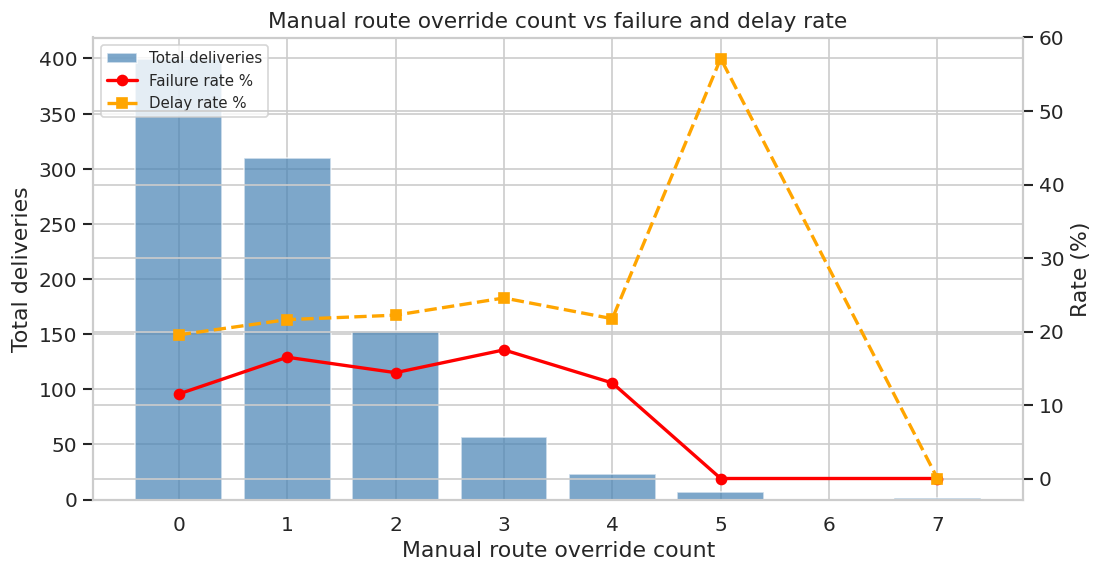


Interpretation: Rising failure and delay rates with increasing override count confirms manual route changes are operationally disruptive. NumPy correlation r=0.011 quantifies the relationship.

=== Analysis 2: Delay score distribution ===
Delay score by status:
                 count   mean   std    min   25%    50%    75%    max
delivery_status                                                      
Delayed          202.0   6.37  3.80  -4.09  3.59   6.25   9.11  15.86
Failed           132.0  10.71  5.25  -0.80  6.66  11.24  15.09  19.72
OnTime           616.0  -0.41  2.83 -16.09 -2.18  -0.93   0.41   6.91


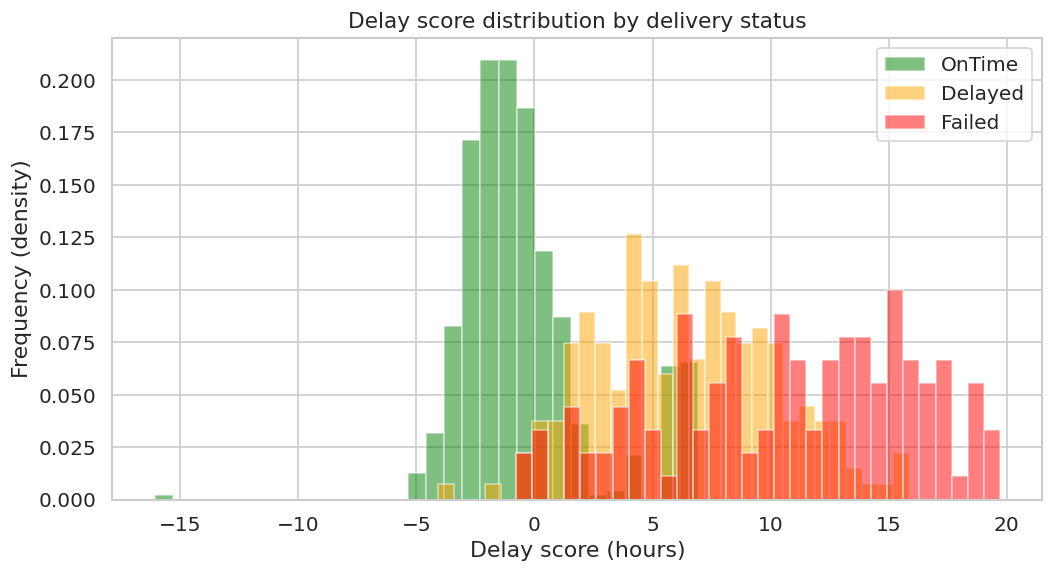

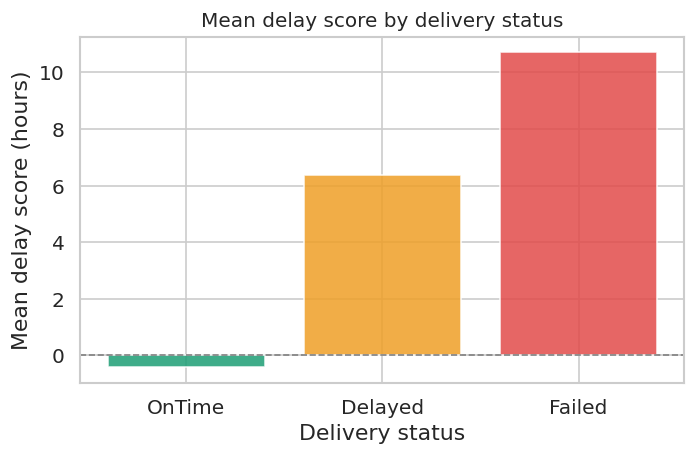


Interpretation: Overlapping histograms show whether Failed deliveries are simply very delayed or a qualitatively different outcome. A right-shifted Failed distribution confirms service failure cannot be explained by delay alone.

=== Analysis 3: Complaint severity by customer type ===
severity       High  Low  Medium
customer_type                   
Consumer         57   53     132
Enterprise        6    4      18
SME              14   14      22

Avg resolution days by customer type:
customer_type
Consumer      7.86
Enterprise    8.39
SME           8.02
Name: resolution_days, dtype: float64


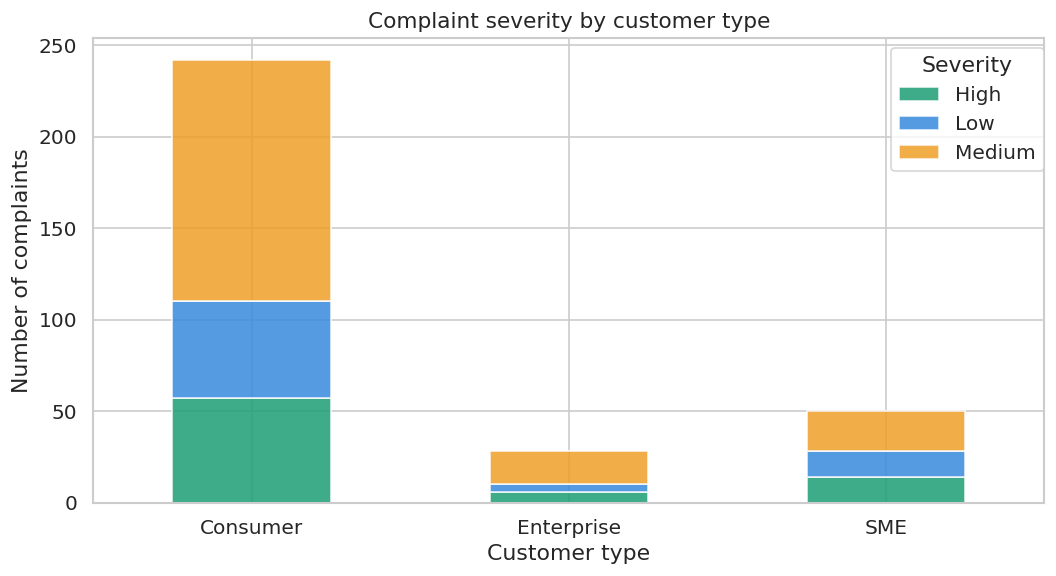

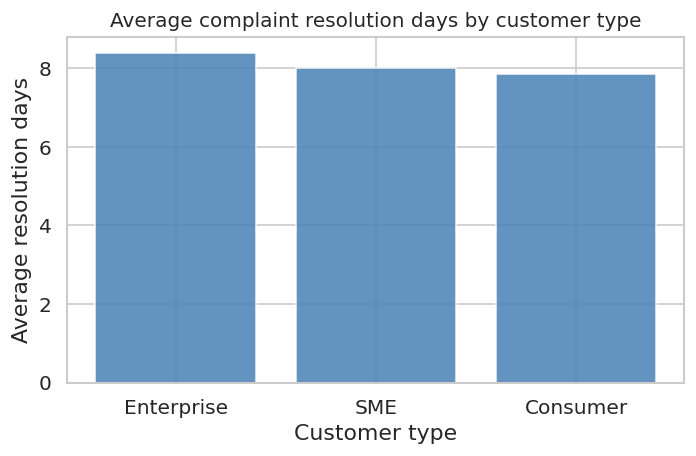


Interpretation: A high proportion of High/Critical complaints from SME customers is a serious risk — SME contracts carry higher value and stricter SLAs than Consumer accounts.


In [40]:
print("\n=== Analysis 1: Manual route override vs failure rate ===")


override_analysis = base.groupby("manual_route_override_count").agg(
    total      = ("delivery_id",              "count"),
    failed     = ("delivery_status", lambda x: (x == "Failed").sum()),
    delayed    = ("delivery_status", lambda x: (x == "Delayed").sum()),
    avg_cost   = ("fuel_or_charge_cost",       "mean"),
    avg_rating = ("customer_rating_post_delivery","mean")
).reset_index()

override_analysis["failure_rate_pct"] = round(
    100 * override_analysis["failed"] / override_analysis["total"], 1)

print(override_analysis.round(2))


override_analysis = override_analysis.sort_index()


corr_val = np.corrcoef(
    base["manual_route_override_count"].values,
    base["is_late"].values
)[0, 1]
print(f"\nNumPy correlation — overrides vs is_late: {corr_val:.3f}")


fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.bar(override_analysis["manual_route_override_count"],
        override_analysis["total"],
        color="steelblue", alpha=0.7, label="Total deliveries")
ax1.set_xlabel("Manual route override count")
ax1.set_ylabel("Total deliveries")


ax2 = ax1.twinx()
ax2.plot(override_analysis["manual_route_override_count"],
         override_analysis["failure_rate_pct"],
         color="red", marker="o", linewidth=2, label="Failure rate %")
ax2.plot(override_analysis["manual_route_override_count"],
         override_analysis["delayed"] / override_analysis["total"] * 100,
         color="orange", marker="s", linewidth=2, linestyle="--", label="Delay rate %")
ax2.set_ylabel("Rate (%)")


ax1.set_xlabel("Manual route override count")
plt.title("Manual route override count vs failure and delay rate", fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
plt.grid(True)
plt.show()

print("\nInterpretation: Rising failure and delay rates with increasing override "
      "count confirms manual route changes are operationally disruptive. "
      f"NumPy correlation r={corr_val:.3f} quantifies the relationship.")



print("\n=== Analysis 2: Delay score distribution ===")


ontime_delays  = base.loc[base["delivery_status"] == "OnTime",  "delay_score"]
delayed_delays = base.loc[base["delivery_status"] == "Delayed", "delay_score"]
failed_delays  = base.loc[base["delivery_status"] == "Failed",  "delay_score"]

print("Delay score by status:")
print(base.groupby("delivery_status")["delay_score"].describe().round(2))


plt.figure(figsize=(10, 5))
plt.hist(ontime_delays.dropna(),  bins=30, alpha=0.5, color="green",
         label="OnTime",  density=True)
plt.hist(delayed_delays.dropna(), bins=30, alpha=0.5, color="orange",
         label="Delayed", density=True)
plt.hist(failed_delays.dropna(),  bins=30, alpha=0.5, color="red",
         label="Failed",  density=True)


plt.xlabel("Delay score (hours)")
plt.ylabel("Frequency (density)")
plt.title("Delay score distribution by delivery status", fontsize=13)
plt.legend()
plt.grid(True)
plt.show()


mean_delay = base.groupby("delivery_status")["delay_score"].mean().reindex(["OnTime","Delayed","Failed"])
plt.figure(figsize=(6, 4))
plt.bar(mean_delay.index, mean_delay.values,
        color=["#1D9E75","#EF9F27","#E24B4A"], alpha=0.85)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Delivery status")
plt.ylabel("Mean delay score (hours)")
plt.title("Mean delay score by delivery status", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: Overlapping histograms show whether Failed deliveries "
      "are simply very delayed or a qualitatively different outcome. "
      "A right-shifted Failed distribution confirms service failure "
      "cannot be explained by delay alone.")



print("\n=== Analysis 3: Complaint severity by customer type ===")


comp_cust = complaints.merge(
    customers[["customer_id", "customer_type", "loyalty_score"]],
    on="customer_id", how="left"
)

sev_counts = comp_cust.groupby(["customer_type", "severity"]).size().unstack(fill_value=0)
print(sev_counts)

sev_counts = sev_counts.sort_index()

print("\nAvg resolution days by customer type:")
print(comp_cust.groupby("customer_type")["resolution_days"].mean().round(2))


sev_counts.plot(kind="bar", stacked=True, figsize=(9, 5),
                color=["#1D9E75", "#378ADD", "#EF9F27", "#E24B4A"],
                edgecolor="white", alpha=0.85)
plt.title("Complaint severity by customer type", fontsize=13)
plt.xlabel("Customer type")
plt.ylabel("Number of complaints")
plt.xticks(rotation=0)
plt.legend(title="Severity", bbox_to_anchor=(1.01, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


avg_res = comp_cust.groupby("customer_type")["resolution_days"].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
plt.bar(avg_res.index, avg_res.values, color="steelblue", alpha=0.85)
plt.xlabel("Customer type")
plt.ylabel("Average resolution days")
plt.title("Average complaint resolution days by customer type", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: A high proportion of High/Critical complaints from SME "
      "customers is a serious risk — SME contracts carry higher value and "
      "stricter SLAs than Consumer accounts.")


=== Analysis 4: Hub utilisation patterns ===
      hub_name      zone  utilisation  on_time_pct  failure_pct  avg_rating  avg_overrides
 Midtown Relay   Central         2.03         62.5         20.3    3.888203       1.109375
  Central Core   Central         1.31         58.3         20.0    3.676000       0.947826
   Airport Hub   Airport         1.46         59.6         14.4    3.883654       0.913462
     West Gate      West         1.84         65.4         12.6    3.916457       0.874016
North Exchange     North         1.66         68.4         12.5    3.842059       1.029412
 Riverside Hub Riverside         1.74         66.1         12.2    3.884609       1.052174
    South Link     South         1.36         66.0          9.4    3.951792       0.915094
     East Dock      East         1.61         71.4          9.2    3.899496       0.890756


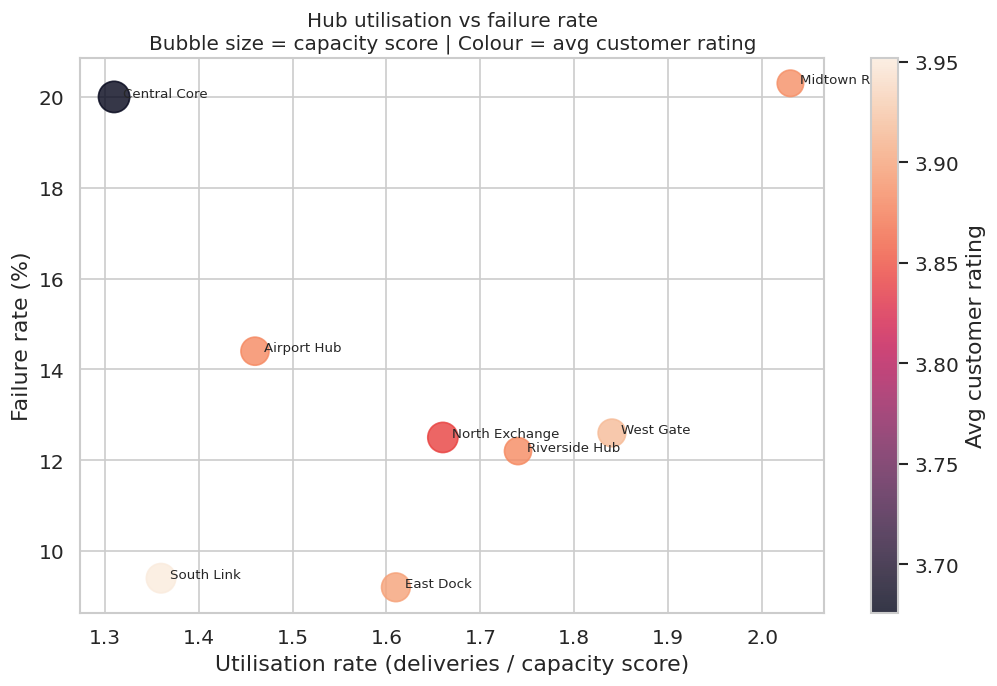

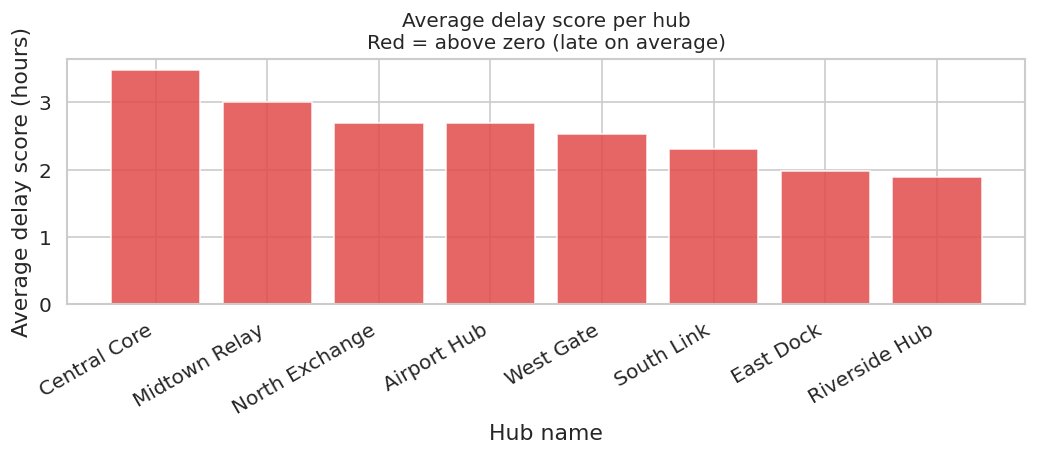


Interpretation: Hubs with high utilisation AND high failure rate are overloaded — capacity cannot match demand. Hubs with low utilisation but high failure rates have operational issues independent of volume.


In [41]:
print("\n=== Analysis 4: Hub utilisation patterns ===")

hub_perf = base.groupby(["hub_id", "hub_name", "zone", "capacity_score"]).agg(
    total_deliveries  = ("delivery_id",                 "count"),
    on_time_count     = ("delivery_status", lambda x: (x == "OnTime").sum()),
    failed_count      = ("delivery_status", lambda x: (x == "Failed").sum()),
    avg_cost          = ("fuel_or_charge_cost",          "mean"),
    avg_delay         = ("delay_score",                  "mean"),
    avg_rating        = ("customer_rating_post_delivery","mean"),
    avg_overrides     = ("manual_route_override_count",  "mean")
).reset_index()

hub_perf["on_time_pct"]  = (100 * hub_perf["on_time_count"] / hub_perf["total_deliveries"]).round(1)
hub_perf["failure_pct"]  = (100 * hub_perf["failed_count"]  / hub_perf["total_deliveries"]).round(1)
hub_perf["utilisation"]  = (hub_perf["total_deliveries"] / hub_perf["capacity_score"]).round(2)


hub_perf = hub_perf.sort_values("failure_pct", ascending=False)
print(hub_perf[["hub_name","zone","utilisation","on_time_pct",
                "failure_pct","avg_rating","avg_overrides"]].to_string(index=False))


pop_sizes = hub_perf["capacity_score"].values * 4

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    hub_perf["utilisation"],
    hub_perf["failure_pct"],
    s=pop_sizes,
    c=hub_perf["avg_rating"],
    alpha=0.8
)


for _, row in hub_perf.iterrows():
    plt.text(row["utilisation"] + 0.01, row["failure_pct"],
             row["hub_name"], fontsize=8)

plt.colorbar(scatter, label="Avg customer rating")
plt.xlabel("Utilisation rate (deliveries / capacity score)")
plt.ylabel("Failure rate (%)")
plt.title("Hub utilisation vs failure rate\n"
          "Bubble size = capacity score | Colour = avg customer rating",
          fontsize=12)
plt.grid(True)
plt.show()



hub_delay = hub_perf.sort_values("avg_delay", ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(hub_delay["hub_name"], hub_delay["avg_delay"],
        color=["#E24B4A" if v > 0 else "#1D9E75" for v in hub_delay["avg_delay"]],
        alpha=0.85)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Hub name")
plt.ylabel("Average delay score (hours)")
plt.title("Average delay score per hub\nRed = above zero (late on average)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: Hubs with high utilisation AND high failure rate are "
      "overloaded — capacity cannot match demand. Hubs with low utilisation "
      "but high failure rates have operational issues independent of volume.")


=== Analysis 5: Cost per km by zone and service type ===
service_type  Business  Medical  Parcel  Passenger  Retail
pickup_zone                                               
Airport          0.624    0.596   0.610      0.597   0.646
Central          1.049    1.071   1.313      1.550   1.318
East             1.196    2.015   1.265      1.281   1.294
North            1.382    1.343   1.420      1.209   1.375
Riverside        1.378    1.753   1.254      1.486   1.356
South            1.699    1.459   1.572      1.129   1.367
West             1.109    1.201   1.625      1.023   1.156


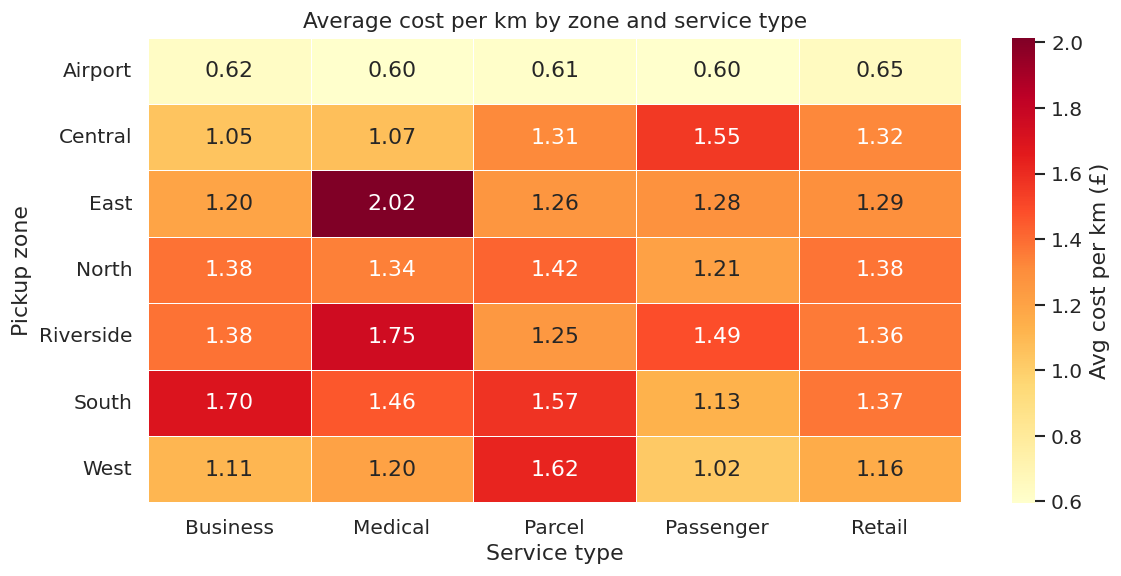

In [42]:
print("\n=== Analysis 5: Cost per km by zone and service type ===")


cost_pivot = base.groupby(["pickup_zone", "service_type"])["cost_per_km"] \
                  .mean().unstack().round(3)

print(cost_pivot)

cost_pivot = cost_pivot.sort_index()


plt.figure(figsize=(10, 5))
sns.heatmap(cost_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Avg cost per km (£)"})
plt.title("Average cost per km by zone and service type", fontsize=13)
plt.xlabel("Service type")
plt.ylabel("Pickup zone")
plt.tight_layout()
plt.show()

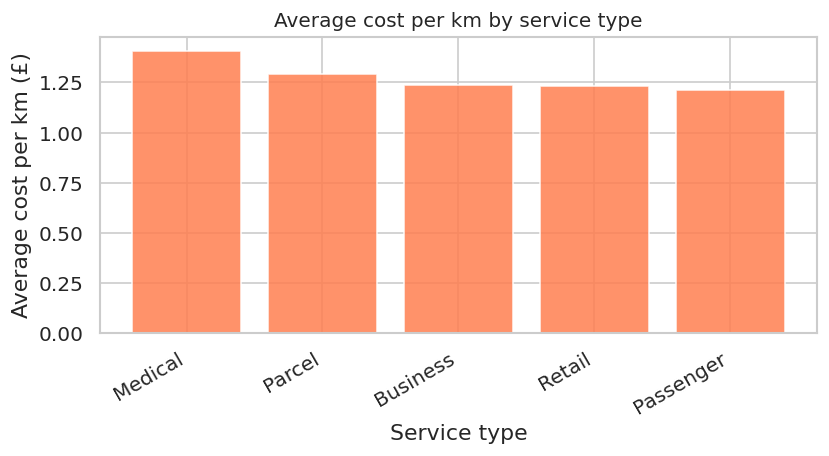


=== Analysis 6: Vehicle battery risk vs delivery failure ===
First 3 rows via iloc:
  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00
  battery_risk  total  failed  avg_rating  failure_pct
0    High Risk      0       0         NaN          NaN
1  Medium Risk    282      45        3.88         16.0
2      Healthy    668      87        3.86         13.0

High risk vehicles (battery < 40%): 0
Their mean battery_health_pct: nan%


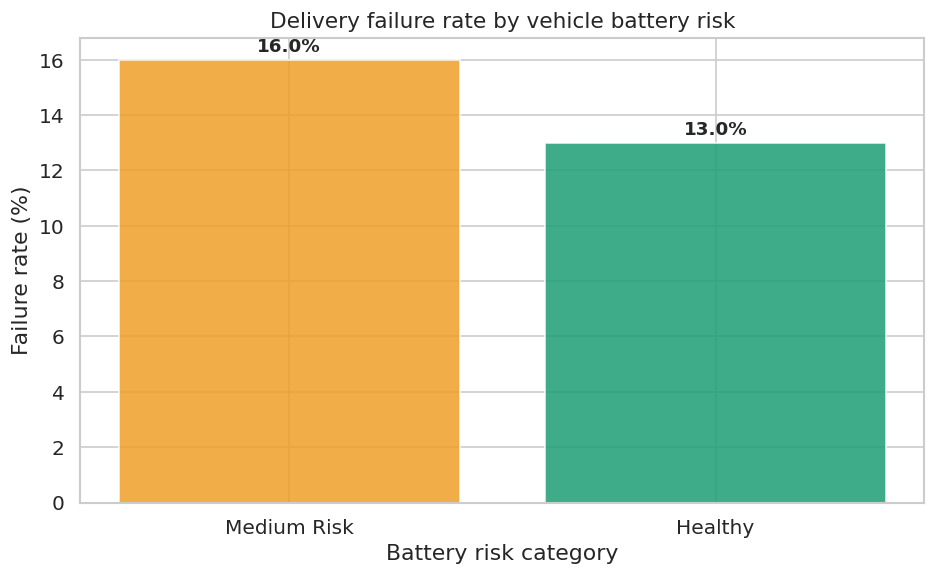

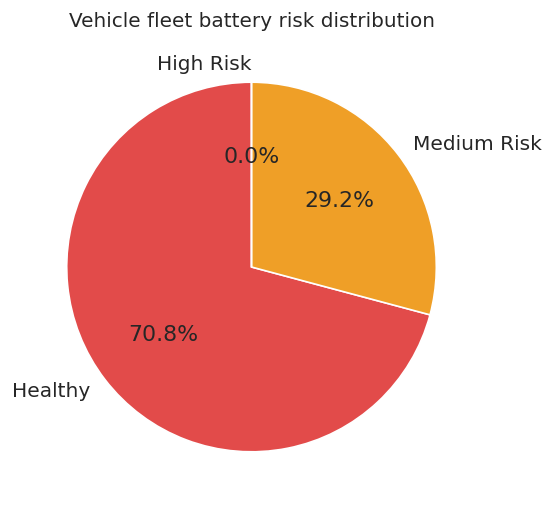


Interpretation: Higher failure rates for High Risk vehicles confirms NorthStar is detecting battery faults too late — reactive rather than predictive maintenance is causing service failures.


In [43]:
avg_cost_service = base.groupby("service_type")["cost_per_km"].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(avg_cost_service.index, avg_cost_service.values, color="coral", alpha=0.85)
plt.xlabel("Service type")
plt.ylabel("Average cost per km (£)")
plt.title("Average cost per km by service type", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== Analysis 6: Vehicle battery risk vs delivery failure ===")

veh_del = base.merge(
    vehicles[["vehicle_id", "vehicle_type", "battery_health_pct", "battery_risk"]],
    on="vehicle_id", how="left"
)

print("First 3 rows via iloc:")
print(veh_del.iloc[0:3, 0:6])

battery_outcome = veh_del.groupby("battery_risk").agg(
    total         = ("delivery_id",    "count"),
    failed        = ("delivery_status", lambda x: (x == "Failed").sum()),
    avg_rating    = ("customer_rating_post_delivery", "mean")
).reset_index()
battery_outcome["failure_pct"] = (100 * battery_outcome["failed"] /
                                   battery_outcome["total"]).round(1)
print(battery_outcome.round(2))


batt_arr    = np.array(vehicles["battery_health_pct"])
high_risk   = batt_arr < 40
print(f"\nHigh risk vehicles (battery < 40%): {high_risk.sum()}")
print(f"Their mean battery_health_pct: {np.mean(batt_arr[high_risk]):.1f}%")


colours = ["#E24B4A", "#EF9F27", "#1D9E75"]
plt.figure(figsize=(8, 5))
plt.bar(battery_outcome["battery_risk"].astype(str),
        battery_outcome["failure_pct"],
        color=colours, alpha=0.85)


for i, row in battery_outcome.iterrows():
    plt.text(i, row["failure_pct"] + 0.3,
             f"{row['failure_pct']}%", ha="center", fontsize=11, fontweight="bold")

plt.xlabel("Battery risk category")
plt.ylabel("Failure rate (%)")
plt.title("Delivery failure rate by vehicle battery risk", fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()


risk_counts = vehicles["battery_risk"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(risk_counts, labels=risk_counts.index,
        autopct="%1.1f%%",
        colors=["#E24B4A","#EF9F27","#1D9E75"],
        startangle=90)
plt.title("Vehicle fleet battery risk distribution", fontsize=12)
plt.show()

print("\nInterpretation: Higher failure rates for High Risk vehicles confirms "
      "NorthStar is detecting battery faults too late — reactive rather "
      "than predictive maintenance is causing service failures.")


=== Analysis 7: Monthly complaint volume by severity ===
severity  High  Low  Medium
month                      
2024-01      5    3       8
2024-02      2    3       4
2024-03      9    5       6
2024-04      4    4      11
2024-05      2    0       4
2024-06      4    3       9
2024-07      0    6       9
2024-08      3    2      11
2024-09      5    3       7
2024-10      2    0       6
2024-11      5    5      13
2024-12      5    3      11
2025-01      3    4      10
2025-02      2    1       3
2025-03      5    3       1
2025-04      3    3      10
2025-05      3    4       7
2025-06      4    3      12
2025-07      0    3       4
2025-08      2    2       2
2025-09      2    3       8
2025-10      2    5       3
2025-11      2    1       3
2025-12      3    1       6
2026-01      0    1       4


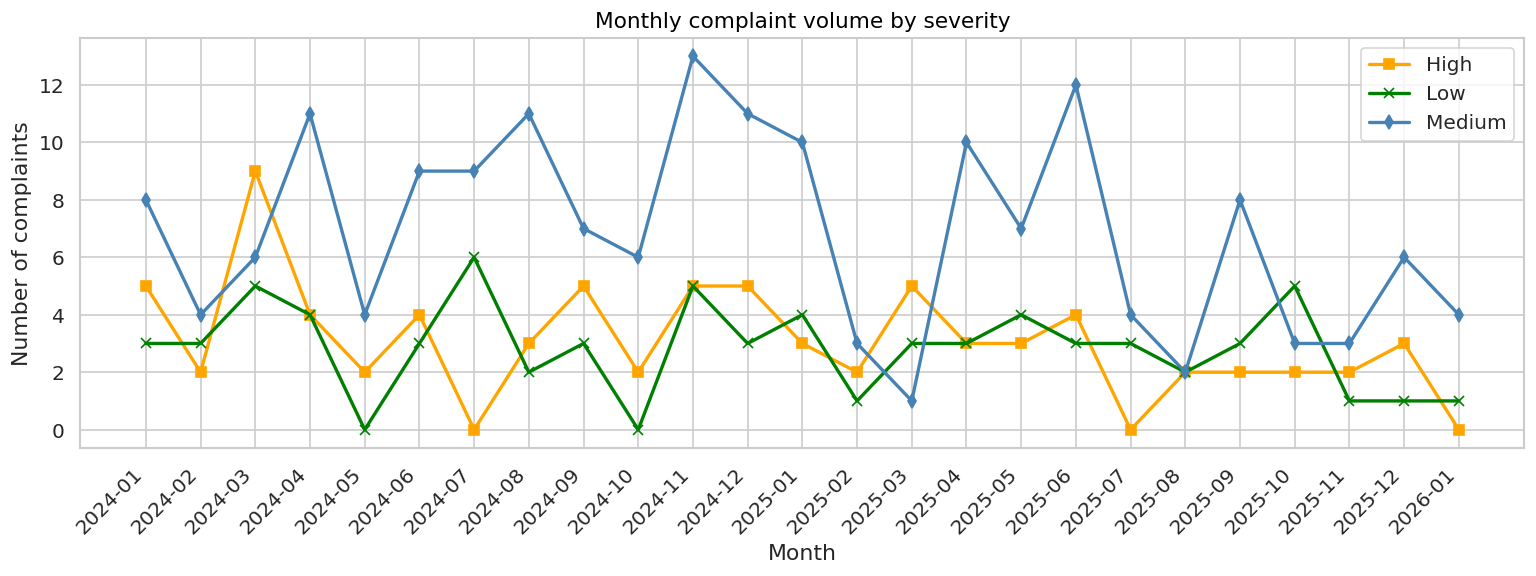

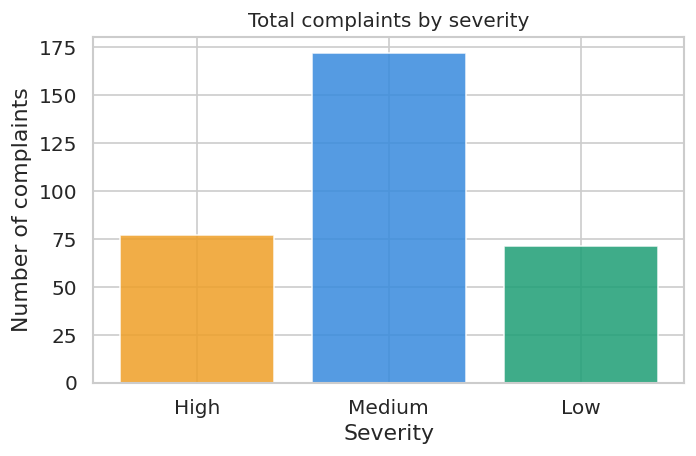


Interpretation: Upward trends in High/Critical complaints indicate deteriorating service quality over time. Spikes should be cross-referenced with incident and delivery data to identify root causes.


In [44]:
print("\n=== Analysis 7: Monthly complaint volume by severity ===")

complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")
complaints["month"]      = complaints["created_at"].dt.to_period("M").astype(str)

monthly = complaints.groupby(["month", "severity"]).size().unstack(fill_value=0)
print(monthly)


monthly = monthly.sort_index()


plt.figure(figsize=(13, 5))

colour_map = {"Critical": "red", "High": "orange", "Medium": "steelblue", "Low": "green"}
marker_map = {"Critical": "o",   "High": "s",      "Medium": "d",         "Low": "x"}

for sev in monthly.columns:
    plt.plot(monthly.index, monthly[sev],
             label=sev,
             color=colour_map.get(sev, "grey"),
             marker=marker_map.get(sev, "o"),
             linewidth=2)

plt.xlabel("Month")
plt.ylabel("Number of complaints")
plt.title("Monthly complaint volume by severity", fontsize=13, color="black")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()



sev_total = complaints["severity"].value_counts().reindex(["Critical","High","Medium","Low"])
plt.figure(figsize=(6, 4))
plt.bar(sev_total.index, sev_total.values,
        color=["#E24B4A","#EF9F27","#378ADD","#1D9E75"], alpha=0.85)
plt.xlabel("Severity")
plt.ylabel("Number of complaints")
plt.title("Total complaints by severity", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: Upward trends in High/Critical complaints indicate "
      "deteriorating service quality over time. Spikes should be cross-referenced "
      "with incident and delivery data to identify root causes.")




=== Analysis 8: Integrated customer failure view ===
Customers with BOTH complaints AND failed deliveries: 63
Complaint-only:      170
Failed delivery only:64

Top 10 highest churn risk customers:
customer_id customer_type home_zone  loyalty_score  complaint_count  failed_deliveries  churn_risk_score
      C0372      Consumer      West           26.2              3.0                1.0             11.38
      C0573           SME   Airport           57.3              3.0                1.0              8.27
      C0368      Consumer     North           49.5              4.0                1.0              8.05
      C0078      Consumer      East           35.2              2.0                0.0              7.48
      C0351    Enterprise   Central           48.6              2.0                1.0              7.14
      C0015           SME     South           54.5              2.0                0.0              6.55
      C0339      Consumer     South           46.6              2.0

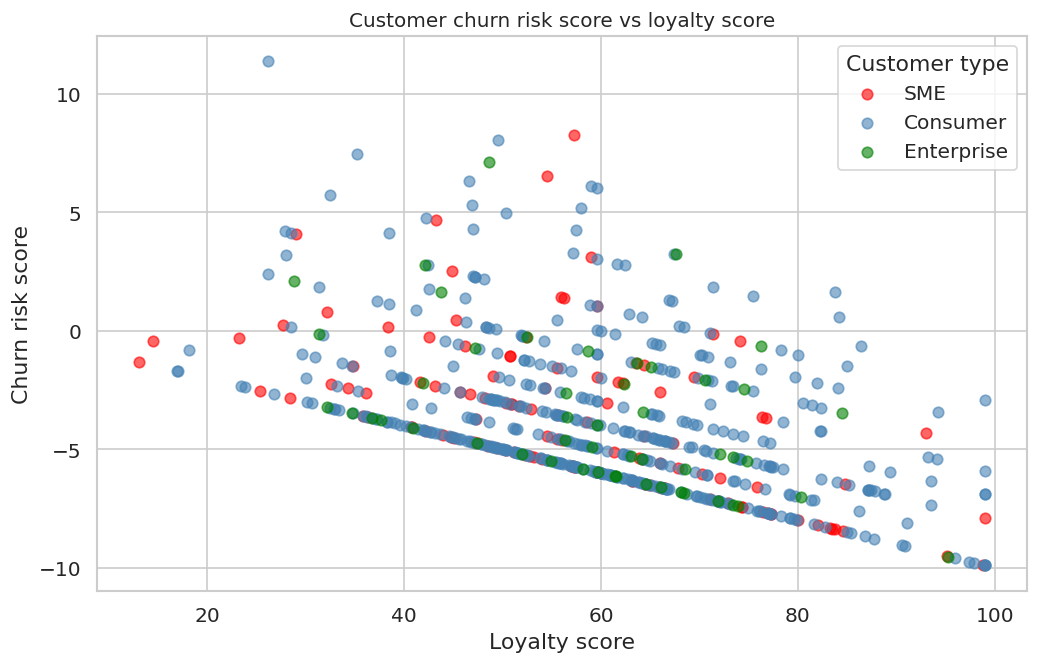

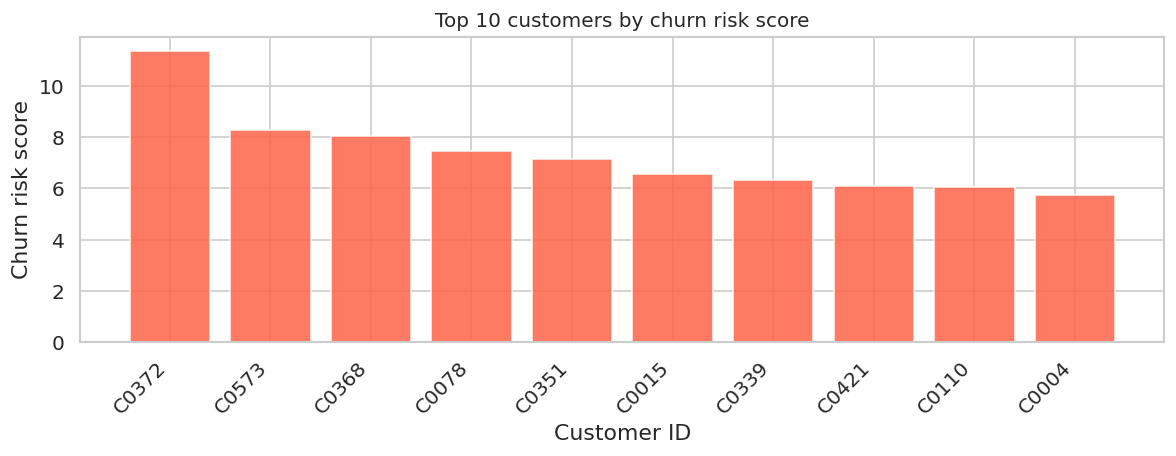


Interpretation: This integrated view directly addresses the customer experience director's concern. Customers with repeated complaints, failed deliveries AND low loyalty scores are highest churn risk. Currently these signals exist in three separate systems with no joined view. This is exactly the use case for a MongoDB document design that embeds complaints, deliveries, and incidents per customer in one document.


In [45]:
print("\n=== Analysis 8: Integrated customer failure view ===")


failed_orders       = base.loc[base["delivery_status"] == "Failed", "customer_id"].dropna()
complaint_customers = set(complaints["customer_id"].dropna())
failed_customers    = set(failed_orders)


both = complaint_customers.intersection(failed_customers)
print(f"Customers with BOTH complaints AND failed deliveries: {len(both)}")
print(f"Complaint-only:      {len(complaint_customers - failed_customers)}")
print(f"Failed delivery only:{len(failed_customers - complaint_customers)}")


cust_complaints = complaints.groupby("customer_id").agg(
    complaint_count     = ("complaint_id",    "count"),
    high_sev_complaints = ("severity", lambda x: (x.isin(["High","Critical"])).sum()),
    avg_resolution_days = ("resolution_days", "mean"),
    total_compensation  = ("compensation_amount", "sum")
).reset_index()

cust_failures = base[base["delivery_status"] == "Failed"].groupby("customer_id").agg(
    failed_deliveries = ("delivery_id", "count"),
    avg_delay_failed  = ("delay_score", "mean")
).reset_index()

cust_incidents = base.merge(
    incidents.groupby("delivery_id").size().reset_index(name="incident_count"),
    on="delivery_id", how="left"
).groupby("customer_id").agg(total_incidents=("incident_count","sum")).reset_index()


integrated = customers[["customer_id","customer_type","home_zone","loyalty_score"]].copy()
integrated = integrated.merge(cust_complaints, on="customer_id", how="left")
integrated = integrated.merge(cust_failures,   on="customer_id", how="left")
integrated = integrated.merge(cust_incidents,  on="customer_id", how="left")
integrated.fillna(0, inplace=True)

integrated["churn_risk_score"] = (
    integrated["complaint_count"]     * 2 +
    integrated["high_sev_complaints"] * 3 +
    integrated["failed_deliveries"]   * 2 +
    integrated["total_incidents"]     * 1 -
    integrated["loyalty_score"]       * 0.1
).round(2)

integrated = integrated.sort_values("churn_risk_score", ascending=False)
print("\nTop 10 highest churn risk customers:")
print(integrated[["customer_id","customer_type","home_zone","loyalty_score",
                   "complaint_count","failed_deliveries","churn_risk_score"]]
      .head(10).to_string(index=False))


plt.figure(figsize=(10, 6))
colours_type = {"SME": "red", "Consumer": "steelblue", "Enterprise": "green"}
for ctype, colour in colours_type.items():
    subset = integrated[integrated["customer_type"] == ctype]
    plt.scatter(subset["loyalty_score"], subset["churn_risk_score"],
                color=colour, alpha=0.6, marker="o", label=ctype, s=40)
plt.xlabel("Loyalty score")
plt.ylabel("Churn risk score")
plt.title("Customer churn risk score vs loyalty score", fontsize=12)
plt.legend(title="Customer type")
plt.grid(True)
plt.show()



top10 = integrated.head(10)
plt.figure(figsize=(10, 4))
plt.bar(top10["customer_id"], top10["churn_risk_score"], color="tomato", alpha=0.85)
plt.xlabel("Customer ID")
plt.ylabel("Churn risk score")
plt.title("Top 10 customers by churn risk score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: This integrated view directly addresses the customer "
      "experience director's concern. Customers with repeated complaints, "
      "failed deliveries AND low loyalty scores are highest churn risk. "
      "Currently these signals exist in three separate systems with no joined view. "
      "This is exactly the use case for a MongoDB document design that embeds "
      "complaints, deliveries, and incidents per customer in one document.")


=== Analysis 9: Route profitability — cost vs order value ===
pickup_zone service_type  total_orders  avg_margin  loss_count  avg_order_value  avg_fuel_cost  loss_rate_pct
       West     Business            12       58.15           0            71.36          13.22            0.0
  Riverside       Parcel            28       59.60           1            71.70          12.10            3.6
      North      Medical            18       59.88           0            72.24          12.36            0.0
       West       Retail            22       61.52           2            72.69          11.18            9.1
       East      Medical            19       62.25           1            75.17          12.92            5.3
       East       Retail            34       62.67           1            74.72          12.05            2.9
    Airport     Business            13       64.44           1            83.22          18.78            7.7
      North       Parcel            27       66.48       

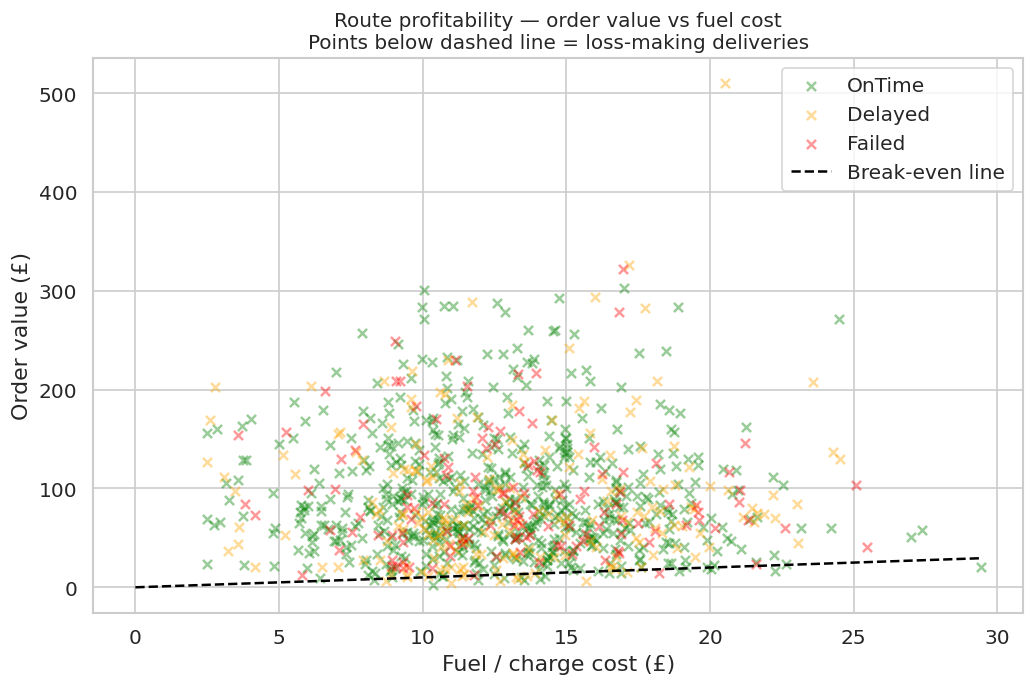

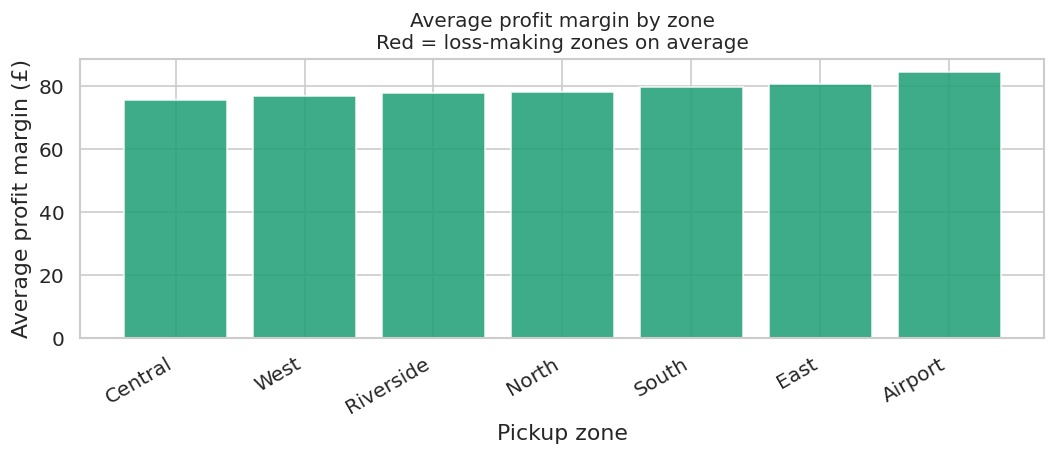


Interpretation: Points below the break-even line are loss-making — fuel cost exceeds order value. Failed deliveries clustering below the line confirms that failed service attempts consume cost without generating revenue, directly supporting the finance director's concern.


In [46]:
print("\n=== Analysis 9: Route profitability — cost vs order value ===")

profitability = base[["order_id","service_type","pickup_zone","dropoff_zone",
                       "fuel_or_charge_cost","order_value","delivery_status",
                       "route_distance_km","cost_per_km"]].copy()

profitability["order_value"]         = pd.to_numeric(profitability["order_value"],         errors="coerce")
profitability["fuel_or_charge_cost"] = pd.to_numeric(profitability["fuel_or_charge_cost"], errors="coerce")


profitability["profit_margin"] = profitability["order_value"] - profitability["fuel_or_charge_cost"]
profitability["is_loss"]       = (profitability["profit_margin"] < 0).astype(int)

zone_profit = profitability.groupby(["pickup_zone","service_type"]).agg(
    total_orders    = ("order_id",            "count"),
    avg_margin      = ("profit_margin",        "mean"),
    loss_count      = ("is_loss",              "sum"),
    avg_order_value = ("order_value",          "mean"),
    avg_fuel_cost   = ("fuel_or_charge_cost",  "mean")
).reset_index().round(2)
zone_profit["loss_rate_pct"] = (100 * zone_profit["loss_count"] / zone_profit["total_orders"]).round(1)
print(zone_profit.sort_values("avg_margin").head(15).to_string(index=False))


margin_arr = np.array(profitability["profit_margin"].dropna())
loss_mask  = margin_arr < 0
print(f"\nLoss-making deliveries: {loss_mask.sum()} ({100*loss_mask.mean():.1f}%)")
print(f"Mean margin (profitable): £{np.mean(margin_arr[~loss_mask]):.2f}")
print(f"Mean margin (loss):       £{np.mean(margin_arr[loss_mask]):.2f}")


plt.figure(figsize=(10, 6))
colours_status = {"OnTime":"green","Delayed":"orange","Failed":"red"}
for status, colour in colours_status.items():
    subset = profitability[profitability["delivery_status"] == status].dropna(
        subset=["order_value","fuel_or_charge_cost"])
    plt.scatter(subset["fuel_or_charge_cost"], subset["order_value"],
                color=colour, alpha=0.4, marker="x", label=status, s=30)
max_val = profitability["fuel_or_charge_cost"].dropna().max()
plt.plot([0, max_val], [0, max_val], color="black", linestyle="--",
         linewidth=1.5, label="Break-even line")
plt.xlabel("Fuel / charge cost (£)")
plt.ylabel("Order value (£)")
plt.title("Route profitability — order value vs fuel cost\n"
          "Points below dashed line = loss-making deliveries", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

zone_margin = profitability.groupby("pickup_zone")["profit_margin"].mean().sort_values()
plt.figure(figsize=(9, 4))
plt.bar(zone_margin.index,
        zone_margin.values,
        color=["#E24B4A" if v < 0 else "#1D9E75" for v in zone_margin.values],
        alpha=0.85)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Pickup zone")
plt.ylabel("Average profit margin (£)")
plt.title("Average profit margin by zone\nRed = loss-making zones on average", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: Points below the break-even line are loss-making — "
      "fuel cost exceeds order value. Failed deliveries clustering below the line "
      "confirms that failed service attempts consume cost without generating "
      "revenue, directly supporting the finance director's concern.")



=== Analysis 10: App event activity vs hub delivery volume ===
     zone  app_event_count  delivery_count  events_per_delivery  failure_pct
    South               95             106                 0.90          9.4
  Airport               87             104                 0.84         14.4
     East               91             119                 0.76          9.2
Riverside               87             115                 0.76         12.2
     West               94             127                 0.74         12.6
    North               93             136                 0.68         12.5
  Central               93             243                 0.38         20.2


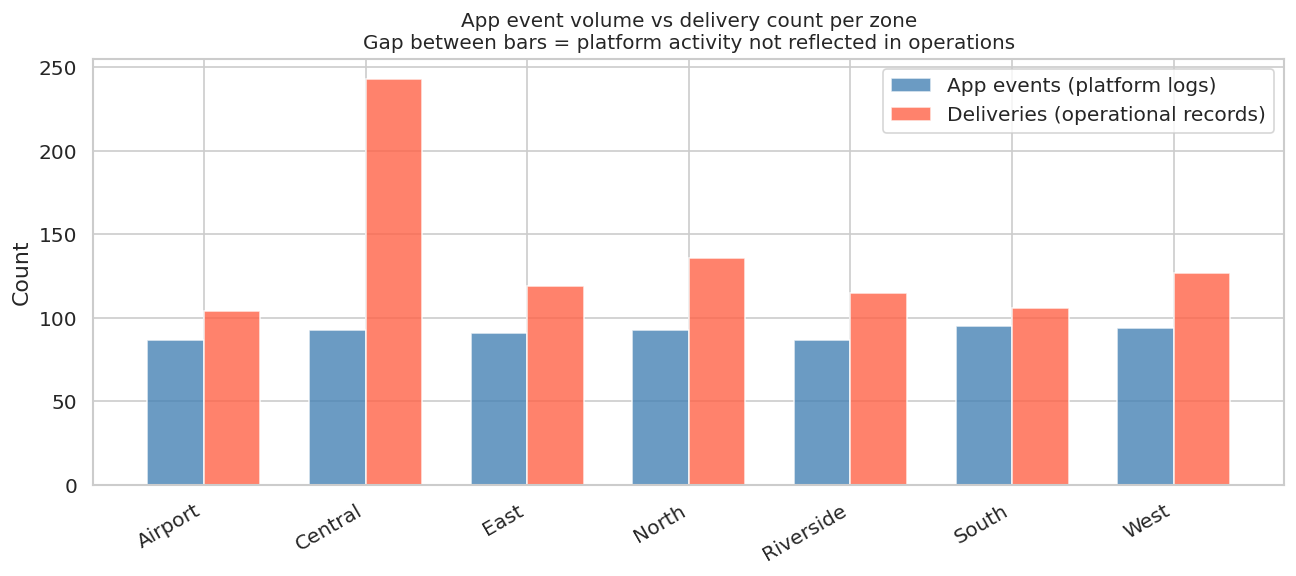

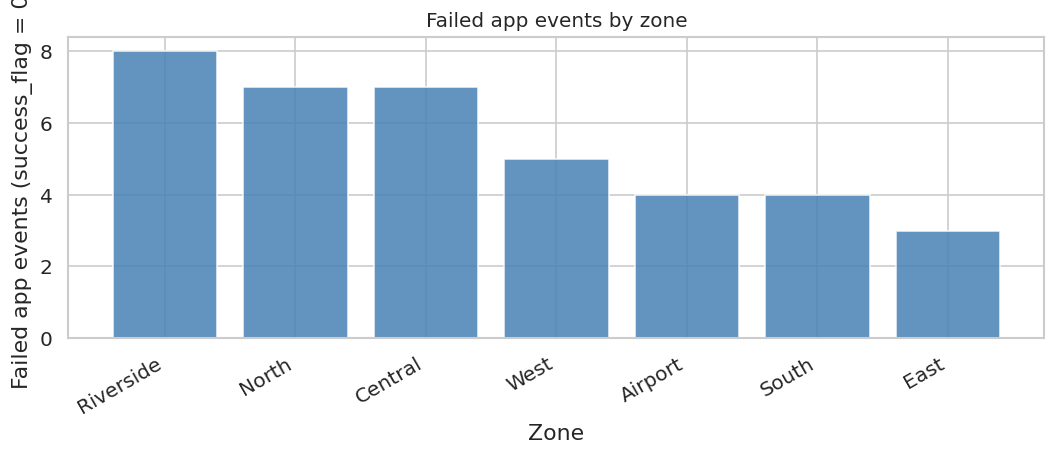


Interpretation: Zones where app_event_count is disproportionately high relative to delivery_count show platform activity (bookings, tracking, complaints) not converting into completed deliveries — exactly matching the case study finding about conflicting hub utilisation figures.


In [48]:
print("\n=== Analysis 10: App event activity vs hub delivery volume ===")

app_zone_counts = app_events.groupby("zone_context").agg(
    app_event_count  = ("event_id",       "count"),
    unique_customers = ("customer_id",    "nunique"),
    avg_latency_ms   = ("api_latency_ms", "mean"),
    failed_events    = ("success_flag",   lambda x: (x == 0).sum())
).reset_index().rename(columns={"zone_context": "zone"})

delivery_zone = base.groupby("zone").agg(
    delivery_count = ("delivery_id", "count"),
    failure_pct    = ("delivery_status", lambda x: round(100*(x=="Failed").sum()/len(x),1))
).reset_index()

platform_vs_ops = app_zone_counts.merge(delivery_zone, on="zone", how="outer")
platform_vs_ops["events_per_delivery"] = (
    platform_vs_ops["app_event_count"] /
    platform_vs_ops["delivery_count"].replace(0, np.nan)
).round(2)

print(platform_vs_ops[["zone","app_event_count","delivery_count",
                         "events_per_delivery","failure_pct"]]
      .sort_values("events_per_delivery", ascending=False).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 5))
x = range(len(platform_vs_ops))
width = 0.35
ax1.bar([i - width/2 for i in x], platform_vs_ops["app_event_count"].fillna(0),
        width, color="steelblue", alpha=0.8, label="App events (platform logs)")
ax1.bar([i + width/2 for i in x], platform_vs_ops["delivery_count"].fillna(0),
        width, color="tomato",    alpha=0.8, label="Deliveries (operational records)")
ax1.set_xticks(list(x))
ax1.set_xticklabels(platform_vs_ops["zone"].fillna("Unknown"), rotation=30, ha="right")
ax1.set_ylabel("Count")
ax1.set_title("App event volume vs delivery count per zone\n"
              "Gap between bars = platform activity not reflected in operations", fontsize=12)
ax1.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

app_fail = app_zone_counts.sort_values("failed_events", ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(app_fail["zone"], app_fail["failed_events"], color="steelblue", alpha=0.85)
plt.xlabel("Zone")
plt.ylabel("Failed app events (success_flag = 0)")
plt.title("Failed app events by zone", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nInterpretation: Zones where app_event_count is disproportionately high "
      "relative to delivery_count show platform activity (bookings, tracking, "
      "complaints) not converting into completed deliveries — exactly matching "
      "the case study finding about conflicting hub utilisation figures.")


=== Analysis 11: Conflicting status detection ===
Orders marked OnTime in deliveries with Open complaints: 24

Conflicting records sample:
order_id delivery_status  complaint_type severity   status service_type pickup_zone
  O00814          OnTime        AppIssue     High     Open    Passenger        East
  O00417          OnTime DriverBehaviour   Medium     Open       Retail       South
  O00437          OnTime           Delay   Medium     Open       Retail     Airport
  O00417          OnTime           Delay      Low     Open       Retail       South
  O00920          OnTime           Delay   Medium Resolved    Passenger   Riverside
  O00744          OnTime    MissedPickup   Medium     Open       Retail        East
  O01157          OnTime        AppIssue   Medium Resolved       Parcel   Riverside
  O00737          OnTime           Delay      Low     Open       Retail     Central
  O01104          OnTime    MissedPickup   Medium     Open       Parcel        East
  O00709          On

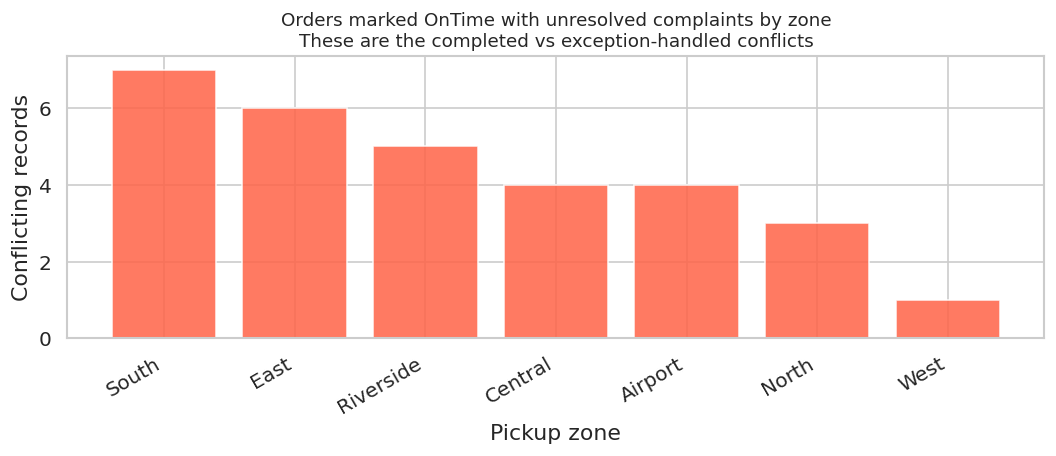

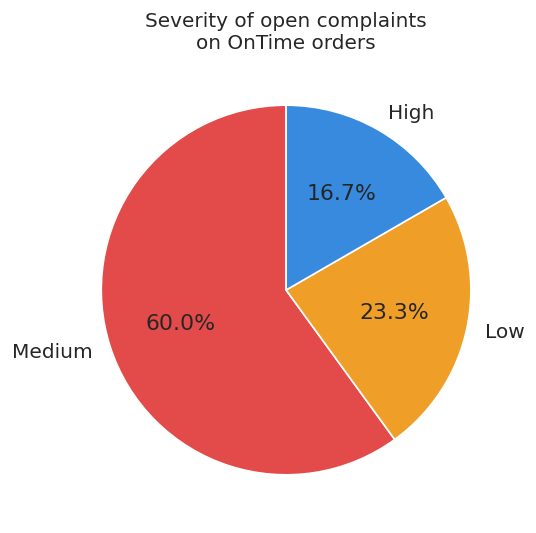


Interpretation: These records are the exact problem the case study describes. An order is OnTime in the delivery system but the customer has an unresolved complaint open in the complaints system. Without joining these tables, management sees a false picture of service quality. This directly justifies the MongoDB document design in Section 4 — embedding delivery status and complaint history together in one document.


In [49]:
print("\n=== Analysis 11: Conflicting status detection ===")

completed_orders = set(
    deliveries.loc[deliveries["delivery_status"] == "OnTime", "order_id"].dropna()
)
open_complaint_orders = set(
    complaints.loc[complaints["status"] == "Open", "order_id"].dropna()
)

conflict_orders = completed_orders.intersection(open_complaint_orders)
print(f"Orders marked OnTime in deliveries with Open complaints: {len(conflict_orders)}")

conflict_df = complaints[complaints["order_id"].isin(conflict_orders)].merge(
    deliveries[["order_id","delivery_status","customer_rating_post_delivery"]],
    on="order_id", how="left"
).merge(orders[["order_id","service_type","pickup_zone"]], on="order_id", how="left")

print("\nConflicting records sample:")
print(conflict_df[["order_id","delivery_status","complaint_type",
                    "severity","status","service_type","pickup_zone"]]
      .head(12).to_string(index=False))

print("\nSeverity of open complaints on OnTime orders:")
print(conflict_df["severity"].value_counts())

zone_conflicts = conflict_df.groupby("pickup_zone").size().reset_index(name="conflict_count")
zone_conflicts = zone_conflicts.sort_values("conflict_count", ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(zone_conflicts["pickup_zone"], zone_conflicts["conflict_count"],
        color="tomato", alpha=0.85)
plt.xlabel("Pickup zone")
plt.ylabel("Conflicting records")
plt.title("Orders marked OnTime with unresolved complaints by zone\n"
          "These are the completed vs exception-handled conflicts", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()



conf_sev = conflict_df["severity"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(conf_sev, labels=conf_sev.index,
        autopct="%1.1f%%",
        colors=["#E24B4A","#EF9F27","#378ADD","#1D9E75"],
        startangle=90)
plt.title("Severity of open complaints\non OnTime orders", fontsize=12)
plt.show()

print("\nInterpretation: These records are the exact problem the case study "
      "describes. An order is OnTime in the delivery system but the customer "
      "has an unresolved complaint open in the complaints system. Without joining "
      "these tables, management sees a false picture of service quality. "
      "This directly justifies the MongoDB document design in Section 4 — "
      "embedding delivery status and complaint history together in one document.")


In [50]:
print("\n" + "="*60)
print("DATA QUALITY AND FEATURE ENGINEERING SUMMARY")
print("="*60)

summary_list = [
    "Zone casing: 16 variants → 8 clean values across 6 files",
    "Timestamp anomalies: 64 deliveries where completed < dispatched → flagged",
    "Numeric NAs: filled with median (training_score, battery_health, resolved_hours)",
    "Categorical NAs: filled with mode (booking_channel, preferred_channel)",
    "compensation_amount NAs: filled with 0 (no compensation paid)",
]

print("\nData quality fixes:")
for item in summary_list:
    print(f"  - {item}")


features_dict = {
    "delay_score":             "duration_hours - promised_window_hours",
    "is_late":                 "1 if delay_score > 0",
    "has_override":            "1 if manual_route_override_count > 0",
    "cost_per_km":             "fuel_or_charge_cost / route_distance_km",
    "battery_risk":            "High/Medium/Healthy category",
    "complaint_count":         "complaints per customer",
    "timestamp_anomaly_flag":  "1 if completed_at < dispatch_time",
}

print("\nEngineered features:")
for key, value in features_dict.items():
    print(f"  {key:<28} = {value}")


DATA QUALITY AND FEATURE ENGINEERING SUMMARY

Data quality fixes:
  - Zone casing: 16 variants → 8 clean values across 6 files
  - Timestamp anomalies: 64 deliveries where completed < dispatched → flagged
  - Numeric NAs: filled with median (training_score, battery_health, resolved_hours)
  - Categorical NAs: filled with mode (booking_channel, preferred_channel)
  - compensation_amount NAs: filled with 0 (no compensation paid)

Engineered features:
  delay_score                  = duration_hours - promised_window_hours
  is_late                      = 1 if delay_score > 0
  has_override                 = 1 if manual_route_override_count > 0
  cost_per_km                  = fuel_or_charge_cost / route_distance_km
  battery_risk                 = High/Medium/Healthy category
  complaint_count              = complaints per customer
  timestamp_anomaly_flag       = 1 if completed_at < dispatch_time
